# CBA on the Effects of Air Pollution

The following code calculates abatement costs and avoided damage costs (benefits) on the effects of the v6 air pollution scenarios compared to the baseline scenario

## Imports

Packages and input files are imported to be used further down in the code


In [111]:
# Import neccessary packages
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.interpolate import interp1d

## Scenario-version

In [112]:
VERSION = "v6b"  

### General

In [113]:
# AP costs
AP_costs = pd.read_excel("Processed_Data/APcosts_check.xlsx")

# Economic regions
region_df = pd.read_excel("Processed_Data/region_allocation_check.xlsx")

### Climate

In [114]:
# Stressor
emissions_input = pd.read_excel("Processed_Data/emissions_check.xlsx")

# Impact
climate_metric = pd.read_excel("Processed_Data/Metric_check.xlsx")

# Economic Values
SC_SLCP = pd.read_excel(r"Processed_Data/SLCF_cost_check.xlsx")

### Health

In [185]:
# Stressors
PM25_input = pd.read_excel("Processed_Data/PM25_check.xlsx")

# State
Inc_R_morb = pd.read_excel("Processed_Data/Morb_incidents.xlsx")
Inc_R_mort = pd.read_excel("Processed_Data/Mort_incidents.xlsx")
pop = pd.read_excel("Processed_Data/POP_5yr.xlsx")
LE_30 = pd.read_excel("Processed_Data/LE_5yr.xlsx")

# Impacts
health_ERF = pd.read_excel("Processed_Data/Health_ERF_check.xlsx")

# Economic Values
morb_costs = pd.read_excel("Processed_Data/Morb_costs_check.xlsx")
VOLY_VSL_costs = pd.read_excel("Processed_Data/Mort_costs_check.xlsx")

### Fertilisation

In [116]:
# Stressors


# State
Ne_to_N = 0.014

# Impacts
BIO_CL = pd.read_excel("Processed_Data/BIO_CL_check.xlsx")

# Economic Values €/kg N
Price_N = 1

### Biodiversity

In [117]:
# Stressors
#PM25_input is used here too

# State

# Impacts
BIO_CL_biodiv = pd.read_excel("Processed_Data/clempn_exc_allecosys_check.xlsx")

# Economic Values

# €/kg N
Brink = pd.DataFrame({
    "Biodiv_level": ["Low","High"],
    "Economic_value": [2.3, 11.3]    
})

# €/1000 km2
Hasler = pd.DataFrame({
    "Biodiv_level": ["Low","High"],
    "Economic_value": [4500000, 13500000]    
})


### Crops

In [118]:
# Impacts
crops_avoided_losses = pd.read_excel("Processed_Data/crops_out_check.xlsx")

# Economic Values euro [€/tonne] (See ICP Vegatation)
crops_econ_input = [
    {"Crop": "Potato", "low": 20, "mid": 36.1, "high": 50},
    {"Crop": "Wheat", "low": 100, "mid": 219.5, "high": 300}
]

crops_econ_values = pd.DataFrame(crops_econ_input)

## Soiling

In [119]:
# Stressors
pm10_conv_fact = pd.read_excel("Processed_Data/pm10_conv_fact.xlsx")

# State
Soiling_area = pd.read_excel("Processed_Data/Soiling_area_check.xlsx")

# Impacts

# Economic Values €/myg/m3/year
soiling_costs = pd.DataFrame({
    "soiling_cost_level": ["Low","Mid", "High"],
    "Economic_value": [22.2, 37, 51.8]    
})

## Consistency Check

Ensuring that the same scenario set is present in all relevant files. This is done by compiling all scenario-specific dataframes and and checking that the values in the scenario column all ends with the correct version denominator.

In [186]:
dfs_check = [emissions_input, PM25_input, BIO_CL, BIO_CL_biodiv, crops_avoided_losses]

if all(df['Scenario'].str.endswith(VERSION).all() for df in dfs_check):
    print("✅ All scenarios end with the correct version denominator")
else:
    raise ValueError("❌ Some scenarios do not end with the correct version denominator")

✅ All scenarios end with the correct version denominator


## Functions

Gather all functions which are to be used later in the CBA

In [187]:
# Merge tables by KEY through

# Sequentially merge all parameter DataFrames using only the shared context keys
# (country, scenario, year). Each DataFrame can contain multiple variants
# (level/type_of_value) per key, so the merge behaves as a many-to-many join,
# generating all valid parameter combinations within each context.

def many_to_many(KEYS, dfs, how, suffixes):
    out = reduce(lambda left_table, right_table: left_table.merge(right_table, on=KEYS, how=how, suffixes=(suffixes)), dfs)

    return(out)


## Define Global Parameters
Define for example economic regions by creating lists to call for later.

### General

In [188]:
Countries = region_df["Country"].unique()

Regions = ['Country', 'EU27', 'EECCA', 'EFTA+UK', 'UNECE Europe', 'UNECE Caucasus + Asia', 'West Balkan', 'NON EU27', 'Nordics'] 

SCENARIOS = {
    "v6b": [
        "A1r/d/D/v6b", "C1/d/D/v6b", "D1/d/D/v6b",
        "C2/d/D/v6b", "D2/d/D/v6b", "D3/d/D/v6b",
        "MTFR_v6b"]
}

BASE_SCENARIO = {
    "v6b": "Base_v6b"
}

Scenarios = SCENARIOS[VERSION]
BASE_Scenario = BASE_SCENARIO[VERSION]

scenario_plot_labels = {
        "A1r/d/D/v6b": "PM-health 50%", 
        "C1/d/D/v6b": "PM-health 50% \nBiodiv. 40%", 
        "D1/d/D/v6b": "PM-health 50% \nBiodiv. 40% \n(excl. 4)",
        "C2/d/D/v6b": "PM-health 50% \nBiodiv. 45%", 
        "D2/d/D/v6b": "PM-health 50% \nBiodiv. 45% \n(excl. 4)", 
        "D3/d/D/v6b": "PM-health 50% \nBiodiv. 50% \n(excl. 4)",
        "MTFR_v6b": "MTFR_v6b"
}

### Climate

In [189]:
Climate_metrics = ['GWP20-E', 'GWP100-E', 'GTP20-E', 'GTP100-E']

### Health

In [190]:
Core = ['Core', 'Non-core']

Mor_cause = ["All", "Specfic"]

Mor_model = ["GAINS", "ARP"]

Cost_type = ['VOLY', 'VSL']

### Crops

In [191]:
Crop_types = ["Wheat", "Potato"]

### Soiling

In [192]:
Soiling_area_sources = ["ICP", "Project_est"]

## Prepping

In order to conduct the CBA on all possible permutations, the input dataframes has to be prepped.

The code must:
1. Allow the user to choose values for certain parameters
2. Ensure traceability after permutations

### General

In [193]:
# Only use the sum of sectors
AP_costs_sector = AP_costs[AP_costs['Sector'] == 'Sum']

# Remove second column of Net AP costs
AP_costs_sector_drop = AP_costs_sector.drop(columns=["Net_AP_Costs"])

# Merge and sum by economic region
AP_costs_ByRegion = many_to_many("Country", [region_df, AP_costs_sector_drop], "left", ["",""])
AP_costs_ByRegion = AP_costs_ByRegion.groupby(["Region", "Scenario", "Sector" , "Year"], as_index=False)["Net AP Costs"].sum()
AP_costs_ByRegion["Country"] = "NA"

# 
AP_costs_ByCountry = AP_costs_sector_drop.copy()
AP_costs_ByCountry["Region"] = "Country"

#
AP_costs_tomerge = pd.concat([AP_costs_ByCountry, AP_costs_ByRegion], ignore_index=True)
AP_costs_tomerge = AP_costs_tomerge[["Region", "Country", "Scenario", "Net AP Costs"]]

### Climate

In [194]:
# Only use the sum of sectors
emissions_input_sector = emissions_input[emissions_input['Sector'] == 'Sum']

# Only use the year 2040
emissions_input_sector_year = emissions_input_sector[emissions_input_sector['Year'] == 2040]
SC_SLCP_year = SC_SLCP[SC_SLCP['Year'] == 2040]
SC_SLCP_year_drop = SC_SLCP_year.drop(columns=["Year"])

# Only use the discount rate of 0.020
SC_SLCP_year_discount = SC_SLCP_year_drop[SC_SLCP_year_drop['Discount rate'] == 0.020]

### Health

In [195]:
# Only use the 'All' of age groups
pop_age = pop[pop['5yr cohort'].isin(['Total', '30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90-94', '95+'])]

health_ERF_age = health_ERF[health_ERF['Age group'] == '30+']

Inc_R_morb_age = Inc_R_morb.loc[Inc_R_morb["5yr cohort"].isin(['30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90-94', '95+'])]
Inc_R_mort_age = Inc_R_mort.loc[Inc_R_mort["5yr cohort"].isin(['30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90-94', '95+'])]

# Only use the year 2040
pop_age_year = pop_age[pop_age['Year'] == 2040]
LE_30_year = LE_30[LE_30['Year'] == 2040]
Inc_R_mort_age_year = Inc_R_mort_age[Inc_R_mort_age['Year'] == 2040]

# YOLL or Mean conc
PM25_input_mean = PM25_input.drop(columns=["YOLL_value", "Premat_deaths"])
PM25_input_yoll = PM25_input.drop(columns=["Mean PM2.5 concentration_value", "Premat_deaths"])
PM25_input_prem_deaths = PM25_input.drop(columns=["Mean PM2.5 concentration_value", "YOLL_value"])

#
VOLY_costs = VOLY_VSL_costs[VOLY_VSL_costs["Cost_type"] == "VOLY"]
VSL_costs = VOLY_VSL_costs[VOLY_VSL_costs["Cost_type"] == "VSL"]

### Fertilisation

In [196]:
# Only use forests
BIO_CL_forests = BIO_CL.loc[BIO_CL['Ecosystem_type'] == "Forest"]

# Splice the df into Base vs other scenarios
BIO_CL_scen = BIO_CL_forests.loc[BIO_CL_forests['Scenario'].isin(Scenarios)]
BIO_CL_base = (BIO_CL_forests[BIO_CL_forests['Scenario'] == BASE_Scenario]).drop(columns=["Area", "Exceeded"])

# Match rows between base and other scenarios and clean
BIO_CL_prepped = many_to_many(["Region","Country", "Year", "Ecosystem_type"], [BIO_CL_scen, BIO_CL_base], "inner", ["_scen", "_base"])  
BIO_CL_prepped = BIO_CL_prepped.drop(columns = ["Scenario_base"]).rename(columns={'Scenario_scen': 'Scenario'})

### Biodiversity

In [197]:
# Map which countries are to be included for analysis
countries_to_include = (region_df[region_df['Region']=="EU27"]["Country"]).to_list()
countries_to_include.extend(["Norway", "Switzerland", "United Kingdom"])

# Use a binary 1/0 column to later multiply with in order to only calculate results for the mapped countries
BIO_CL_biodiv['binary'] = BIO_CL_biodiv['Country'].isin(countries_to_include).map({True: 1, False: 0})

### Crops

In [198]:
# Melting the df as to only have one Delta column
crops_econ_values_long = crops_econ_values.melt(
    id_vars=['Crop'],
    var_name="Econ_level",
    value_name="Econ_value"
)

### Soiling

In [199]:
# Extract only total populations for 2040
pop_total = pop[pop["5yr cohort"]=="Total"]
pop_total_2040 = pop_total[pop_total["Year"]==2040].drop(columns=["Year"])


## Combining

Sequentially merge all parameter DataFrames using only the shared context keys and keep all columns to ensure tracebility. 

The code builds upon the "many-to-many merge problem" and uses Cartisian product.

### Climate

In [200]:
# Create the KEY which matches rows between dfs
KEYS_em = ["Pollutant"]

# Merge all dfs pertaining to the Climate CBA using the correct KEY
out_em = many_to_many(KEYS_em, [emissions_input_sector_year, 
                                climate_metric,              
                                SC_SLCP_year_discount], "inner", ["",""]) 

### Health

In [201]:
# Create the KEYS which matches rows between dfs. Different KEYS are required for each merging step
KEYS_pm_1 = ["Country", "Year", "5yr cohort"]
KEYS_pm_2 = ["Health_outcome"]
KEYS_pm_3 = ["Country", "Year"]

# Merge all dfs pertaining to MORBIDITY
out_morb_1 = many_to_many(KEYS_pm_1, [pop_age_year, Inc_R_morb_age], "inner", ["",""])
out_morb_2 = many_to_many(KEYS_pm_2, [out_morb_1, health_ERF_age], "inner", ["",""]) # Assume ERF true and homogenous for all cohorts within 30+ age group
out_morb_3 = many_to_many(KEYS_pm_3, [out_morb_2, PM25_input_mean], "inner", ["",""])

# Merge all dfs pertaining to MORTALITY
out_mort_1 = many_to_many(KEYS_pm_1, [pop_age_year, Inc_R_mort_age_year], "inner", ["",""])
out_mort_2 = many_to_many(KEYS_pm_2, [out_mort_1, health_ERF_age], "inner", ["",""]) # Assume ERF true and homogenous for all cohorts within 30+ age group
out_mort_3 = many_to_many(KEYS_pm_3, [out_mort_2, PM25_input_mean], "inner", ["",""])

### Fertilisation

In [202]:
# Merge all dfs pertaining to the Fertilisation CBA
BIO_CL_prepped["Ne to N"] = Ne_to_N
BIO_CL_prepped["Price N"] = Price_N

### Soiling

In [203]:
# Create the KEY which matches rows between dfs
KEYS_soil = ["Country"]

# Merge all dfs pertaining to the Climate CBA using the correct KEY
out_soil_temp = many_to_many(KEYS_soil, [Soiling_area, PM25_input_mean, 
                                         pm10_conv_fact, pop_total_2040], 
                                   "inner", ["",""])

# Merge with residual dfs without KEYs
out_soil = out_soil_temp.merge(soiling_costs, how="cross")

## Computing

Compute the results of all values within a row and insert a Results column. 

The equation used to compute each row depends on the CBA sub-category.

### Climate

Eq:

$$
\text{Impact} =
\text{Emissions} \cdot \text{Climate Metric} \cdot \text{Economic Metric}
$$

Where:

- $\text{Emissions}$ = amount of pollutant present in atmosphere [tonne]
- $\text{Climate Metric}$ = conversion metric to find the climate forcing value [tonne CO2/CH4eq / tonne pollutant] 
- $\text{Economic Metric}$ = economic values per tPollutant [€/tonne pollutant]

In [204]:
# Collect all columns holding parameter values
value_cols_em = [c for c in out_em.columns if c.endswith("_value")]

# Compute the result for each permutation by multiplying all parameter values row-wise according to the Climate-equation
out_em["Results"] = out_em[value_cols_em].prod(axis=1)

Eq 2:

$$
\text{Benefits}_{\text{Climate}} = \text{Impact (Base)} - \text{Impact (Scenario)}_{\text{i}}
$$


In [205]:
#KEYS for further matching between dataframes
KEYS_em_delta = ["Region", "Country", "Climate_metric", "Level"]

# Group the Climate results by country, sum accross all pollutants
out_em_country = (out_em.groupby(["Region", "Country", "Scenario", "Climate_metric", "Level"], as_index=False)["Results"].sum())

# Split the df by Base scenario from the others
out_em_country_base = out_em_country[out_em_country['Scenario'] == BASE_Scenario]
out_em_country_scenarios = out_em_country.loc[out_em_country['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
out_em_delta = many_to_many(KEYS_em_delta, [out_em_country_scenarios, out_em_country_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_em_delta["Benefits"] = out_em_delta["Results_base"] - out_em_delta["Results_scen"]

# Rename one scenario column
out_em_delta = out_em_delta.rename(columns={'Scenario_scen': 'Scenario'})

# Split for region allocation
out_em_delta_country = out_em_delta[out_em_delta["Region"] == "Country"].copy()
out_em_delta_region = out_em_delta[out_em_delta["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
out_em_region = out_em_delta_region.groupby(["Region", "Scenario", "Climate_metric", "Level"], as_index=False)["Benefits"].sum()

# Merge again
Climate_benefits = pd.concat([out_em_delta_country, out_em_region], ignore_index=True)

# Remove NaN 
Climate_benefits["Country"] = Climate_benefits["Country"].fillna("NA")
Climate_benefits = Climate_benefits.rename(columns={"Benefits": "Benefits_climate"})

# Re-order
Climate_benefits = Climate_benefits[["Region", "Country", "Scenario", "Climate_metric", "Level", "Benefits_climate"]]

#### Per Pollutant

In [206]:
#KEYS for further matching between dataframes
KEYS_em_delta_poll = ["Region", "Country", "Climate_metric", "Level", "Pollutant"]

# Group the Climate results by country, sum accross all pollutants
out_em_country_poll = (out_em.groupby(["Region", "Country", "Scenario", "Pollutant", "Climate_metric", "Level"], as_index=False)["Results"].sum())

# Split the df by Base scenario from the others
out_em_country_base_poll = out_em_country_poll[out_em_country_poll['Scenario'] == BASE_Scenario]
out_em_country_scenarios_poll = out_em_country_poll.loc[out_em_country_poll['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
out_em_delta_poll = many_to_many(KEYS_em_delta_poll, [out_em_country_scenarios_poll, out_em_country_base_poll], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_em_delta_poll["Benefits"] = out_em_delta_poll["Results_base"] - out_em_delta_poll["Results_scen"]

# Rename one scenario column
out_em_delta_poll = out_em_delta_poll.rename(columns={'Scenario_scen': 'Scenario'})

# Split for region allocation
out_em_delta_country_poll = out_em_delta_poll[out_em_delta_poll["Region"] == "Country"].copy()
out_em_delta_region_poll = out_em_delta_poll[out_em_delta_poll["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
out_em_region_poll = out_em_delta_region_poll.groupby(["Region", "Scenario", "Pollutant", "Climate_metric", "Level"], as_index=False)["Benefits"].sum()

# Merge again
Climate_benefits_poll = pd.concat([out_em_delta_country_poll, out_em_region_poll], ignore_index=True)

# Remove NaN 
Climate_benefits_poll["Country"] = Climate_benefits_poll["Country"].fillna("NA")
Climate_benefits_poll = Climate_benefits_poll.rename(columns={"Benefits": "Benefits_climate"})

# Re-order
Climate_benefits_poll = Climate_benefits_poll[["Region", "Country", "Scenario", "Pollutant", "Climate_metric", "Level", "Benefits_climate"]]


### Health

#### ARP
Eq 1:

$$
\text{Impact}_{\text{Deaths/Cases}} =
\text{POP} \cdot \text{Inc\_R}
\left(
1 - e^{\frac{-\ln(\text{ERF})}{10}\cdot \Delta C}
\right)
$$


Where:

- $\text{POP}$ = affected population (within a specific 5 year age cohort)  
- $\text{Inc\_R}$ = Incidence rate, cases per 100,000 persons (within a specific 5 year age cohort)  
- $\text{ERF}$ = Exposure–Response Function, relative risk (RR) per $10\,\mu g/m^3$ exposure increment  
- $\Delta C$ = change in exposure, $\mu g/m^3$


In [207]:
# MORBIDITY
# Compute the result for each permutation by multiplying all parameter values row-wise according to the Health-equation 
out_morb_3["Cases"] = (
    (out_morb_3["pop_value"]/100000)
    * out_morb_3["Morb_value"]
    * (
        1
        - np.exp(
            (-np.log(out_morb_3["Effect_value"]) / 10)
            * out_morb_3["Mean PM2.5 concentration_value"]
        )
    )
)


#MORTALITY
# Compute the result for each permutation by multiplying all parameter values row-wise according to the Health-equation 
out_mort_3["Deaths"] = (
    (out_mort_3["pop_value"]/100000)
    * out_mort_3["Mort_value"]
    * (
        1
        - np.exp(
            (-np.log(out_mort_3["Effect_value"]) / 10)
            * out_mort_3["Mean PM2.5 concentration_value"]
        )
    )
)



Eq 2 Mortality:

$$
\text{YOLL} = \text{Impact}_{\text{Deaths}} \cdot \text{LE} 
$$

Where:

- $\text{YOLL}$ = Years of Life Losts
- $\text{LE}$ = Life expectancy of affected population (within a specific 5 year age cohort)  


$$
\text{Benefits}_{\text{Mortality}}(YOLL) = (\text{YOLL (Base)} - \text{YOLL (Scenarios)}) \cdot \text{VOLY} 
$$
$$
\text{Benefits}_{\text{Mortality}}(Deaths) = (\text{Impact (Base)}_{\text{Deaths}} - \text{Impact (Scenarios)}_{\text{Deaths}}) \cdot \text{VSL} 
$$

Where:

- $\text{VOLY}$ = Value of Life Year, per years of life lost and region/country
- $\text{VSL}$ = Value of Statistical Life, per life lost and region/country 

Eq 2 Morbidity:

$$
\text{Benefits}_{\text{Morbidity}} = (\text{Impact (Base)}_{\text{Cases}} - \text{Impact (Scenarios)}_{\text{Cases}}) 
\cdot \text{Morb\_C}
$$

Where:

- $\text{Morb\_C}$ = Economic valuation of morbidity case, per health outcome, country, and evaluation type (Healthcare, Disultility, Productivity loss)  

In [208]:
# MORTALITY

# Add LE
KEYS_mort_4 = ["Country", "Year", "5yr cohort"]
out_mort_4 = many_to_many(KEYS_mort_4, [out_mort_3, LE_30_year], "inner", ["",""])

# Multiply LE with 
out_mort_4["YOLL"] = out_mort_4["Deaths"] * out_mort_4["LE_value"]

out_mort_4_test = out_mort_4.copy()

# Group 5yr cohorts into one age group 30+
out_mort_4 = out_mort_4.groupby(["Region", "Country", "Scenario", "Health_outcome", 
                                 "Mort_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Deaths", "YOLL"]].sum()

# Split base and scenarios

# KEYS for further matching between dataframes
KEYS_mort_delta = ["Region", "Country", "Health_outcome", 
                 "Mort_level", "Core", "Age group", "Effect_level", "Mor_cause"]

# Split the df by Base scenario from the others
out_mort_base = out_mort_4[out_mort_4['Scenario'] == BASE_Scenario]
out_mort_scenarios = out_mort_4.loc[out_mort_4['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_pm_delta
out_mort_delta = many_to_many(KEYS_mort_delta, [out_mort_scenarios, out_mort_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_mort_delta["Delta_Deaths"] = out_mort_delta["Deaths_base"] - out_mort_delta["Deaths_scen"]
out_mort_delta["Delta_YOLL"] = out_mort_delta["YOLL_base"] - out_mort_delta["YOLL_scen"]

# Rename one scenario column
out_mort_delta = out_mort_delta.rename(columns={'Scenario_scen': 'Scenario'})

# Melting the df as to only have one Delta column
out_mort_delta_long = out_mort_delta.melt(
    id_vars=['Region', 'Country', 'Scenario', 'Health_outcome', 'Mort_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause', 'Deaths_scen', 'YOLL_scen',
       'Scenario_base', 'Deaths_base', 'YOLL_base'],
    var_name="Delta_type",
    value_name="Delta_value"
)

In [209]:
# MORBIDITY

# Group 5yr cohorts into one age group 30+
out_morb_3 = out_morb_3.groupby(["Country", "Scenario", "Health_outcome", 
                                 "Morb_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Cases"]].sum()

# Split base and scenarios

# KEYS for further matching between dataframes
KEYS_morb_delta = ["Country", "Health_outcome", 
                 "Morb_level", "Core", "Age group", "Effect_level", "Mor_cause"]

# Split the df by Base scenario from the others
out_morb_base = out_morb_3[out_morb_3['Scenario'] == BASE_Scenario]
out_morb_scenarios = out_morb_3.loc[out_morb_3['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_pm_delta
out_morb_delta = many_to_many(KEYS_morb_delta, [out_morb_scenarios, out_morb_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_morb_delta["Delta_Cases"] = out_morb_delta["Cases_base"] - out_morb_delta["Cases_scen"]

# Rename one scenario column
out_morb_delta = out_morb_delta.rename(columns={'Scenario_scen': 'Scenario'})

# Melting the df as to only have one Delta column
out_morb_delta_long = out_morb_delta.melt(
    id_vars=['Country', 'Scenario', 'Health_outcome', 'Morb_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause', 'Cases_scen',
       'Scenario_base', 'Cases_base'],
    var_name="Delta_type",
    value_name="Delta_value"
)

In [210]:
# MORTALITY

# Split between Delta_type
out_mort_delta_deaths = out_mort_delta_long[out_mort_delta_long["Delta_type"] == "Delta_Deaths"]
out_mort_delta_yoll = out_mort_delta_long[out_mort_delta_long["Delta_type"] == "Delta_YOLL"]

# Merge with VOLY or VSL
out_mort_delta_deaths_vsl = many_to_many(["Region", "Country"], [out_mort_delta_deaths, VSL_costs], "inner", ["",""])
out_mort_delta_yoll_voly = many_to_many(["Region", "Country"], [out_mort_delta_yoll, VOLY_costs], "inner", ["",""])

# Concate the two dfs
out_mort_benefits = pd.concat([out_mort_delta_yoll_voly, out_mort_delta_deaths_vsl], ignore_index=True)
out_mort_benefits["Mor_value"] = pd.to_numeric(out_mort_benefits["Mor_value"], errors="coerce")

# out_mort_benefits.loc[out_mort_benefits["Region"] == "Country", "Mor_value"] = 95770.06569

# Multiply to find Benefits
out_mort_benefits["Benefits"] = out_mort_benefits["Delta_value"] * out_mort_benefits["Mor_value"]


In [211]:
# MORBIDITY

# KEYS for further matching between dataframes
KEYS_morb_benefits = ["Country", "Health_outcome"]

# Merge the delta_df with morbidity costs
out_morb_benefits = out_morb_delta_long.merge(morb_costs, on=KEYS_morb_benefits, how="left")

# Multiply to find Benefits
out_morb_benefits["Benefits"] = out_morb_benefits["Delta_value"] * out_morb_benefits["Mor_value"]

#Clean
out_morb_benefits.insert(0, "Region", out_morb_benefits.pop("Region"))


#### Group

Group and sum the benefits by different calculation and valuation methods

In [212]:
# MORTALITY

# ---- Split and group the benefits by different economic zones as allocated in the Region column ---- #

# Split df into two
mort_country = out_mort_benefits[out_mort_benefits["Region"]=="UNECE (Excluding North America)"].copy()
mort_country["Region"] = "Country"
mort_regions = out_mort_benefits.copy()

# Group them seperatly
mort_country_gr = mort_country.groupby(["Region", "Country", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()
mort_regions_gr = mort_regions.groupby(["Region", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()

# Merge again
out_mort_grouped_ben = pd.concat([mort_country_gr, mort_regions_gr], ignore_index=True)

# Remove NaN 
out_mort_grouped_ben["Country"] = out_mort_grouped_ben["Country"].fillna("NA")


In [213]:
# MORBIDITY

# ---- Split and group the benefits by different economic zones as allocated in the Region column ---- #

# Split df into two
morb_country = out_morb_benefits[out_morb_benefits["Region"] == "Country"]
morb_regions = out_morb_benefits[out_morb_benefits["Region"] != "Country"]

# Group them seperatly
morb_country_gr = morb_country.groupby(["Region", "Country", "Scenario", "Morb_level", 
                                           "Core", "Age group", "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()
morb_regions_gr = morb_regions.groupby(["Region", "Scenario", "Morb_level", 
                                           "Core", "Age group", "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits"].sum()

# Merge again
morb_benefits_gr = pd.concat([morb_country_gr, morb_regions_gr], ignore_index=True)

# Remove NaN 
morb_benefits_gr["Country"] = morb_benefits_gr["Country"].fillna("NA")

# ---- Sum the MORBIDITY benefits by mor_type, thus sum "Disutility", "Productivity loss", "Healthcare" ----#

# Sum the benefits by mor_type, thus sum "Disutility", "Productivity loss", "Healthcare"
morb_benefits_gr_non_core = morb_benefits_gr.groupby(["Region", "Country", "Scenario", "Morb_level", "Effect_level"], 
                                                   as_index=False, dropna=False)["Benefits"].sum()
morb_benefits_gr_non_core["Core"] = "Non-core"

# Drop all rows which aren't Non-core
indices_to_drop_core = morb_benefits_gr[morb_benefits_gr['Core'] == "Non-core"].index
morb_benefits_gr_core = morb_benefits_gr.drop(indices_to_drop_core)

morb_benefits_gr_core = morb_benefits_gr_core.groupby(["Region", "Country", "Scenario", "Morb_level", "Effect_level"], 
                                                   as_index=False, dropna=False)["Benefits"].sum()
morb_benefits_gr_core["Core"] = "Core"

# Merge the two dfs into one
out_morb_grouped_ben = pd.concat([morb_benefits_gr_non_core, morb_benefits_gr_core], ignore_index=True)

In [214]:
out_mort_benefits_table = out_mort_benefits[(out_mort_benefits["Region"].isin(["UNECE (Excluding North America)"])) & 
                        (out_mort_benefits["Core"] == "Core") &
                        (out_mort_benefits["Cost_type"] == "VOLY") & 
                        (out_mort_benefits["Mor_cause"] == "All")& 
                        (out_mort_benefits["Mort_level"] == "Mid")& 
                        (out_mort_benefits["Effect_level"] == "Mid")]

table_summed_yoll =  out_mort_benefits_table.groupby(["Region", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_scen"].sum()
table_summed_yoll_base =  out_mort_benefits_table.groupby(["Region", "Scenario_base", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_base"].sum()

table_summed_yoll = table_summed_yoll.rename(columns={"YOLL_scen": "YOLL"})
table_summed_yoll_base = table_summed_yoll_base.rename(columns={"YOLL_base": "YOLL", "Scenario_base": "Scenario"})

YOLL_table = pd.concat([table_summed_yoll, table_summed_yoll_base], ignore_index=True)


Amount of morbidity and mortality cases per eco_region for 2040 and 30+

In [215]:
Base_deaths = out_mort_benefits[['Region', 'Country', 'Scenario_base', 'Health_outcome', 'Mort_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause',  'Deaths_base']].copy()

Base_deaths = Base_deaths.groupby(["Region", "Scenario_base", 
                                 "Mort_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Deaths_base"]].sum()


Base_cases = morb_regions[['Region', 'Country', 'Scenario_base', 'Health_outcome', 'Morb_level', 'Core',
       'Age group', 'Effect_level', 'Mor_cause',  'Cases_base']].copy()

Base_cases = Base_cases.groupby(["Region", "Scenario_base", 
                                 "Morb_level", "Core", "Age group", "Effect_level", "Mor_cause"], as_index=False)[
                                ["Cases_base"]].sum()


# with pd.ExcelWriter("Processed_Data/deaths_and_cases_2040.xlsx") as writer:
#     Base_deaths.to_excel(writer, sheet_name="Deaths", index=False)
#     Base_cases.to_excel(writer, sheet_name="Morb Cases", index=False)

In [216]:
# BOTH

# ---- Merge and sum the benefits row-wise to determine the total benefit from both morb and mort ---- #

# Many to merge them using a KEY
KEYS_morb_to_mort = ['Region', "Country", 'Scenario', 'Effect_level']
out_pm_region_mor = many_to_many(KEYS_morb_to_mort, [out_morb_grouped_ben, out_mort_grouped_ben], "inner", ["_morb","_mort"])

# Calculate the benefits by adding "Benefits_x" with "Benefits_y"
out_pm_region_mor["Benefits_health"] = out_pm_region_mor["Benefits_morb"] + out_pm_region_mor["Benefits_mort"]

# Add mor_model
out_pm_region_mor["Mor_model"] = "ARP"

# Clean Processed_Data file
Health_benefits_ARP = out_pm_region_mor[["Region", "Country", 'Scenario', 'Morb_level', 'Mort_level', 'Effect_level', "Core", "Mor_cause", "Mor_model", "Cost_type", "Benefits_health"]]


#### GAINS Model

In [217]:
# Split the df by Base scenario from the others
out_pm_base_yoll = PM25_input_yoll[PM25_input_yoll['Scenario'] == BASE_Scenario]
out_pm_scenarios_yoll = PM25_input_yoll.loc[PM25_input_yoll['Scenario'].isin(Scenarios)]

out_pm_base_premd = PM25_input_prem_deaths[PM25_input_prem_deaths['Scenario'] == BASE_Scenario]
out_pm_scenarios_premd = PM25_input_prem_deaths.loc[PM25_input_prem_deaths['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_pm_delta
out_pm_yoll_delta = many_to_many(["Country", "Year"], [out_pm_scenarios_yoll, out_pm_base_yoll], "inner", ["_scen", "_base"]) 

out_pm_premd_delta = many_to_many(["Country", "Year"], [out_pm_scenarios_premd, out_pm_base_premd], "inner", ["_scen", "_base"]) 

# Compute the difference for each row by removing the scenario values from base values.
out_pm_yoll_delta["Delta_value"] = out_pm_yoll_delta["YOLL_value_base"] - out_pm_yoll_delta["YOLL_value_scen"]

out_pm_premd_delta["Delta_value"] = out_pm_premd_delta["Premat_deaths_base"] - out_pm_premd_delta["Premat_deaths_scen"]

# Rename one scenario column
out_pm_yoll_delta = out_pm_yoll_delta.rename(columns={'Scenario_scen': 'Scenario'})

out_pm_premd_delta = out_pm_premd_delta.rename(columns={'Scenario_scen': 'Scenario'})

#Clean
out_pm_yoll_delta = out_pm_yoll_delta[["Country", "Year", "Scenario", "Delta_value"]]

out_pm_premd_delta = out_pm_premd_delta[["Country", "Year", "Scenario", "Delta_value"]]

In [218]:
mort_yoll = many_to_many("Country", [VOLY_costs, out_pm_yoll_delta], "left", ["", "_df2"])  
mort_prem = many_to_many("Country", [VSL_costs, out_pm_premd_delta], "left", ["", "_df2"])

mort_yoll["Benefits"] = mort_yoll["Mor_value"] * mort_yoll["Delta_value"]  
mort_prem["Benefits"] = mort_prem["Mor_value"] * mort_prem["Delta_value"]

mort_GAINS = pd.concat([mort_yoll, mort_prem], ignore_index=True)

# Drop blank rows (no country)
mort_GAINS = mort_GAINS.dropna()

mort_country_GAINS = mort_country[mort_country["Mor_cause"]=="All"]
mort_region_GAINS = mort_regions[mort_regions["Mor_cause"]=="All"]

# 4) Merge 
mort_country_GAINS_2 = many_to_many(["Region", "Country", "Cost_type", "Scenario"], [mort_country_GAINS, mort_GAINS], "left", ["", "_df2"])
mort_region_GAINS_2 = many_to_many(["Region", "Country", "Cost_type", "Scenario"], [mort_region_GAINS, mort_GAINS], "left", ["", "_df2"])

# Group them seperatly
mort_country_gr_GAINS = mort_country_GAINS_2.groupby(["Region", "Country", "Scenario", "Mort_level", 
                                            "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits_df2"].sum()
mort_regions_gr_GAINS = mort_region_GAINS_2.groupby(["Region", "Scenario", "Mort_level", 
                                            "Effect_level", "Mor_cause", "Cost_type"], as_index=False)["Benefits_df2"].sum()


# Merge again
mort_benefits_gr_GAINS = pd.concat([mort_country_gr_GAINS, mort_regions_gr_GAINS], ignore_index=True)

# Remove NaN 
mort_benefits_gr_GAINS["Country"] = mort_benefits_gr_GAINS["Country"].fillna("NA")

mort_benefits_gr_GAINS = mort_benefits_gr_GAINS.rename(columns={'Benefits_df2': 'Benefits'})

# Add mor_model
mort_benefits_gr_GAINS["Mor_model"] = "GAINS"

In [219]:
# BOTH

# ---- Merge and sum the benefits row-wise to determine the total benefit from both morb and mort ---- #

# Many to merge them using a KEY
KEYS_morb_to_mort = ['Region', "Country", 'Scenario', 'Effect_level']
out_pm_region_mor_GAINS = many_to_many(KEYS_morb_to_mort, [out_morb_grouped_ben, mort_benefits_gr_GAINS], "inner", ["_morb","_mort"])
out_pm_region_mor_GAINS["Benefits_mort"] = pd.to_numeric(out_pm_region_mor_GAINS["Benefits_mort"], errors="coerce")

# Calculate the benefits by adding "Benefits_x" with "Benefits_y"
out_pm_region_mor_GAINS["Benefits_health"] = out_pm_region_mor_GAINS["Benefits_morb"] + out_pm_region_mor_GAINS["Benefits_mort"]

# Clean output file
Health_benefits_GAINS = out_pm_region_mor_GAINS[["Region", "Country", 'Scenario', 'Morb_level', 'Mort_level', 'Effect_level', "Core", "Mor_cause", "Mor_model", "Cost_type", "Benefits_health"]]


#### MERGE

In [220]:
#KEEEP
Health_benefits = pd.concat([Health_benefits_ARP, Health_benefits_GAINS], ignore_index=True)

### Fertilisation

Eq:

$$
\Delta_{\text{AAE}} = \text{Forest}_{\text{AAE}}(Baseline) - \text{Forest}_{\text{AAE}}(Scenario)
$$

$$
\text{Negative Impact [kg]} = \Delta_{\text{AAE}} \cdot \text{Forest Area}_{\text{Total}} \cdot 
(1 - \text{Forest Area}_{\text{Exceeded}}) \cdot \text{Conversion Factor}_{\text{Ne to N}}
$$

$$
\text{Negative Impact [euro]} = \text{Negative Impact [kg]} \cdot \text{Price}_{\text{N}}
$$

Where:

- $\text{AAE}$ = Average Accumulated Exceedance, the Accumulated Exceedance (AE) is used as a metric for the level of exceedance of the recommended critical load (CL) for a particular habitat. The Average Accumulated Exceedance (AAE) is used as a metric of the exceedance across all N-sensitive habitats. 
- $\text{Forest Area}_{\text{Total}}$ = Total forest area.
- $\text{Forest Area}_{\text{Exceeded}}$ = Total forest area which has exceeded the recomended CL.
- $\text{Conversion Factor}_{\text{Ne to N}}$ = Conversion factor between nitrogen equivalents (Ne) and nitrogen (N).
- $\text{Price}_{\text{N}}$ = The price of nitrogen fertiliser.

In [221]:
# Calculate Delta_AAE
BIO_CL_prepped["Delta_AAE"] = BIO_CL_prepped["AAE_base"] - BIO_CL_prepped["AAE_scen"]

# Calculate the Negative Impact [tonne]
BIO_CL_prepped["Negative Impact [kg]"] = (
   BIO_CL_prepped["Delta_AAE"] * 100000 * 
       BIO_CL_prepped["Area"] * (
           1 - BIO_CL_prepped["Exceeded"]/100) *
               BIO_CL_prepped["Ne to N"])

# Calculate the Negative Impact [euro]
BIO_CL_prepped["Negative Impact [euro]"] =  BIO_CL_prepped["Negative Impact [kg]"] * BIO_CL_prepped["Price N"]

In [222]:
# Split for region allocation
fert_country = BIO_CL_prepped[BIO_CL_prepped["Region"] == "Country"].copy()
fert_region = BIO_CL_prepped[BIO_CL_prepped["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
fert_region_merged = fert_region.groupby(["Region", "Scenario"], as_index=False)["Negative Impact [euro]"].sum()
fert_region_merged["Country"] = "NA"
fert_country = fert_country[["Region", "Country", "Scenario", "Negative Impact [euro]"]]

# Merge again
Fertilisation_benefits = pd.concat([fert_country, fert_region_merged], ignore_index=True)

# Remove NaN 
Fertilisation_benefits["Country"] = Fertilisation_benefits["Country"].fillna("NA")
Fertilisation_benefits = Fertilisation_benefits.rename(columns={"Negative Impact [euro]": "Benefits_fertilisation"})

# Multiply by -1 to show lost benefits
Fertilisation_benefits["Benefits_fertilisation"] = Fertilisation_benefits["Benefits_fertilisation"]*(-1)

### Biodiversity

Eq:

$$
\text{Benefits}_{\text{Biodiv}} = \text{Avoided Restauration Costs}_{\text{Semi-natural}} + \text{Avoided Damage Costs}_{\text{Forest}} 
$$

$$
\text{Avoided Restauration Costs}_{\text{Semi-natural}} = \text{Area}_{\text{Semi-natural}} \cdot \text{Exc}_{\text{area}}/100 \cdot \text{R}_{\text{Costs}}
$$

$$
\text{Avoided Damage Costs}_{\text{Forest}} = \text{AAE} \cdot 1000 \cdot \text{Ne-N}_{\text{eq}} \cdot \text{Area}_{\text{Forests}}
$$

Base - scenario

Where:
- $\text{Exc}_{\text{area}}$ = Percent of area which has exceed critical load levels
- $\text{R}_{\text{Costs}}$ = Cost of restoring 1000km2 to pre pollution levels
- $\text{Area}_{\text{Ecosystem type}}$ = Total area of said ecosystem type
- $\text{Ne-N}_{\text{eq}}$ = Nutrient equivalents of Nitrogen 



In [223]:
BIO_CL_biodiv["Amount_exc_N"] = BIO_CL_biodiv["AAE"] * Ne_to_N * 100000 * BIO_CL_biodiv["Area"] 
BIO_CL_biodiv["Exc_area"] = BIO_CL_biodiv["Area"] * BIO_CL_biodiv["Exceeded"]/100

# Find benefits by subtracting scenario from base
KEYS_biodiv_delta = ["Region", "Country", "Year", "Ecosystem_type", "binary"]

# Split the df by Base scenario from the others
BIO_CL_biodiv_base = BIO_CL_biodiv[BIO_CL_biodiv['Scenario'] == BASE_Scenario]
BIO_CL_biodiv_scenarios = BIO_CL_biodiv.loc[BIO_CL_biodiv['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
out_biodiv_delta = many_to_many(KEYS_biodiv_delta, [BIO_CL_biodiv_scenarios, BIO_CL_biodiv_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
out_biodiv_delta["Delta_exc_N"] = out_biodiv_delta["Amount_exc_N_base"] - out_biodiv_delta["Amount_exc_N_scen"]
out_biodiv_delta["Delta_exc_area"] = out_biodiv_delta["Exc_area_base"] - out_biodiv_delta["Exc_area_scen"]

out_biodiv_forest = out_biodiv_delta[(out_biodiv_delta["Ecosystem_type"] == "Forest")]
out_biodiv_semi = out_biodiv_delta[(out_biodiv_delta["Ecosystem_type"] == "Semi_natural")]


In [224]:
# Merge with econ values 
out_biodiv_forest = out_biodiv_forest.merge(Brink, how="cross")
out_biodiv_semi = out_biodiv_semi.merge(Hasler, how="cross")

# Multiply with econ values and the binary value. This ensures that only countries with active biodiversity policies are included in the analysis
out_biodiv_forest["Benefits_biodiv"] = out_biodiv_forest["Delta_exc_N"] * out_biodiv_forest["Economic_value"] * out_biodiv_forest["binary"] 
out_biodiv_semi["Benefits_biodiv"] = out_biodiv_semi["Delta_exc_area"] * out_biodiv_semi["Economic_value"] * out_biodiv_forest["binary"] 

out_biodiv = pd.concat([out_biodiv_forest, out_biodiv_semi], ignore_index=True)

out_biodiv = out_biodiv.rename(columns={"Scenario_scen": "Scenario"})

#Biodiv_benefits = out_biodiv[['Region', 'Country', 'Year', 'Scenario', 'Ecosystem_type', 'Delta_exc_N', 'Brink_level', 'Economic_value', 'Benefits_biodiv']]

# Split for region allocation
biodiv_country = out_biodiv[out_biodiv["Region"] == "Country"].copy()
biodiv_region = out_biodiv[out_biodiv["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the two.
biodiv_region = biodiv_region.groupby(["Region", "Scenario", "Ecosystem_type", "Biodiv_level"], as_index=False)["Benefits_biodiv"].sum()
biodiv_region["Country"] = "NA"
biodiv_country = biodiv_country[["Region", "Country", "Scenario", "Ecosystem_type", "Biodiv_level", "Benefits_biodiv"]]

# Merge again
Biodiv_benefits_by_eco_type = pd.concat([biodiv_country, biodiv_region], ignore_index=True)

Biodiv_benefits = Biodiv_benefits_by_eco_type.groupby(["Region", "Country", "Scenario", "Biodiv_level"], as_index=False)["Benefits_biodiv"].sum()


### Crops

Eq:

$$
\text{Benefits}_{\text{Crop}} = (\text{Avoided\_prod\_loss (Scenario)}_{\text{Crop}} - \text{Avoided\_prod\_loss (Base)}_{\text{Crop}}) \cdot \text{Price}_{\text{Crop}} 
$$

Base - scenario

Where:
- $\text{Avoided\_prod\_loss}_{\text{Crop}}$ = The avoided loss of crops during production as a consequence of lower air pollution levels
- $\text{Price}_{\text{Crop}} $ = Price of sold crops

In [225]:
# Split the df by Base scenario from the others
crops_base = crops_avoided_losses[crops_avoided_losses['Scenario'] == BASE_Scenario]
crops_scenarios = crops_avoided_losses.loc[crops_avoided_losses['Scenario'].isin(Scenarios)]

# Match rows between base and other scenarios by KEYS_em_delta
crops_delta = many_to_many("Crop", [crops_scenarios, crops_base], "inner", ["_scen", "_base"])  

# Compute the difference for each row by removing the scenario values from base values.
crops_delta["Delta_avoided_losses"] = crops_delta["Avoided_prod_losses_weight_scen"] - crops_delta["Avoided_prod_losses_weight_base"]

# Match rows between crops and econ_values by crop_type
crops_delta_econ = many_to_many("Crop", [crops_delta, crops_econ_values_long], "inner", ["", ""]) 

crops_delta_econ["Benefits"] = crops_delta_econ["Delta_avoided_losses"] * crops_delta_econ["Econ_value"]

crops_delta_econ_cleaned = crops_delta_econ[["Scenario_scen", "Crop", "Delta_avoided_losses", "Econ_level", "Benefits"]]
crops_delta_econ_cleaned = crops_delta_econ_cleaned.rename(columns={"Scenario_scen": "Scenario"})

crops_delta_econ_wheat = crops_delta_econ_cleaned[crops_delta_econ_cleaned["Crop"] =="Wheat"].copy()
crops_delta_econ_potato = crops_delta_econ_cleaned[crops_delta_econ_cleaned["Crop"] =="Potato"].copy()

# Match rows between crops and econ_values by crop_type
crops_benefits_all = many_to_many(["Scenario", "Econ_level"], [crops_delta_econ_wheat, crops_delta_econ_potato], "inner", ["_wheat", "_potato"]) 

crops_benefits_all["Benefits_crops"] = crops_benefits_all["Benefits_wheat"] + crops_benefits_all["Benefits_potato"]

crops_benefits = crops_benefits_all.copy()

crops_benefits["Region"] = "UNECE (Excluding North America)"

crops_benefits["Country"] = "NA"

Crops_benefits = crops_benefits[["Region", "Country", "Scenario", "Econ_level", "Benefits_crops"]]

### Soiling

Eq:

$$
\text{Benefits}_{\text{Soiling}} = \frac{\text{Surface area} * \text{Population} * \text{M. Costs per m2}}{\text{Maintenance Interval}}
$$

Base - scenario

Where:
- $\text{Surface area}$: The amount of surface area per person within a country
- $\text{Population}$: The population of a country
- $\text{M. Costs per m2}$: Maintenance costs per square meter
- $\text{Maintenance Interval}$: The amount of years after which the reflectance of a surface is decreased by more than 30% and needs to be cleaned.

$$
\text{Maintenance Interval} =  \frac{-\ln(\frac{\text{PM10}_{\text{conc.}}}{a})}{b}
$$

Where:
- $\text{PM10}_{\text{conc.}}$: The concentration of PM10 in the air
- $a$, $b$: Factors which needs to be interpolated from known points


#### Interpolation of maintenance interval function

In [226]:
# The two known points from literature
x = np.array([25, 10])
y = np.array([10, 25])

# Fit y = a * e^(bx)
coeffs = np.polyfit(x, np.log(y), 1)
b = coeffs[0]
a = np.exp(coeffs[1])

# The fitted function
def inverse_f(y):
    return np.log(y / a) / b

#### Use the interpolated function to calculate the benefits

In [227]:
# Compute the PM10 conc. for each row by mulitplying PM2.5 conc. with conversion factor.
out_soil["PM10_concentration_value"] = out_soil["Mean PM2.5 concentration_value"]*out_soil["av_conv_fact"]

# Compute maintance interval years using interpolated function
out_soil["Maintenance_intervals"] = inverse_f(out_soil["PM10_concentration_value"])

# Compute total maintenance costs by mulipyling area per citizen by population and soiling costs
out_soil["Total_maintenance_costs"] = out_soil["Facade_area"] * out_soil["pop_value"] * out_soil["Economic_value"]

# Compute annualised maintenance costs by dividing total maintenance costs by maintenance intervals
out_soil["Annual_M_costs"] = out_soil["Total_maintenance_costs"] / out_soil["Maintenance_intervals"]

# Split the df by Base scenario from the others
out_soil_base = out_soil[out_soil['Scenario'] == BASE_Scenario].copy()
out_soil_scenarios = out_soil.loc[out_soil['Scenario'].isin(Scenarios)].copy()

# Match rows between base and other scenarios by KEYS_pm_delta
out_soil_delta = many_to_many(['Region', 'Country', 'Source', 'Facade_level', 'Facade_area', 'Year',
                               'av_conv_fact', '5yr cohort', 'pop_value', 'soiling_cost_level', 'Economic_value'], 
                                 [out_soil_scenarios, out_soil_base], "inner", ["_scen", "_base"]) 

# Compute the difference for each row by removing the scenario values from base values.
out_soil_delta["Benefits_soiling"] = (out_soil_delta["Annual_M_costs_base"] - 
                                     out_soil_delta["Annual_M_costs_scen"])

# Clean the df from uneccessary columns
out_soil_benefits = out_soil_delta[["Region", "Country", "Year", "Source", "Scenario_scen", "Facade_level", 
                                    "soiling_cost_level", "Benefits_soiling"]].rename(columns={"Scenario_scen": "Scenario"})

# Split the df between Region equal to Country or not equal to Country
out_soil_benefits_country = out_soil_benefits[out_soil_benefits["Region"] == "Country"].copy()
out_soil_benefits_region = out_soil_benefits[out_soil_benefits["Region"] != "Country"].copy()

# Group the benefits in _regions by region, thus sum all countries within the regions.
out_soil_benefits_regional_sum = out_soil_benefits_region.groupby(["Region", "Year",  "Source", "Scenario", "Facade_level", "soiling_cost_level"], 
                                                                    as_index=False)["Benefits_soiling"].sum()
out_soil_benefits_regional_sum["Country"] = "NA"

# Merge again
Soiling_benefits = pd.concat([out_soil_benefits_country, out_soil_benefits_regional_sum], ignore_index=True)

## Calculate B/C Ratio

The results of a CBA can be presented as the B/C Ratio, a.k.a. the total amount of benefits divided by the total amount of costs. If the ratio is >1, the benefits outweights the costs and it is profitable to pay the price to receive the benefits. If the ratio is <1, it is more beneficial to not pay the costs and not receive the benefits.

$$
\text{B/C Ratio} = \frac{\text{Benefits}_{\text{Total}}}{\text{AP Costs}}
$$

In [228]:
# KEYS for further matching between dataframes
KEYS_benfits_tot = ["Region", "Country", "Scenario"]

# Use many_to_merge in order to match and merge Health and Climate benefits 
Benefits_climate_health_fert_biodiv_crops = many_to_many(KEYS_benfits_tot, [Health_benefits, Climate_benefits, 
                                                                            Biodiv_benefits, Fertilisation_benefits, 
                                                                            Soiling_benefits], "inner", ["", ""]) #Crops_benefits

# Calculate the Benefits_total by summing benefits health and climate 
Benefits_climate_health_fert_biodiv_crops["Benefits_total"] = (Benefits_climate_health_fert_biodiv_crops["Benefits_health"] + 
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_climate"] + 
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_biodiv"] + 
                                                              Benefits_climate_health_fert_biodiv_crops["Benefits_fertilisation"] +
                                                              #Benefits_climate_health_fert_biodiv_crops["Benefits_crops"] +
                                                              +Benefits_climate_health_fert_biodiv_crops["Benefits_soiling"])

# KEYS for further matching between dataframes
KEYS_BC = ["Region", "Country", "Scenario"]

# Use many_to_merge in order to match and merge total benefits df and AP Costs
BC_ratio = many_to_many(KEYS_BC, [Benefits_climate_health_fert_biodiv_crops, AP_costs_tomerge], "inner", ["","_AP"])

# Save one version for step-wise calcs
BC_Step_Wise = BC_ratio.copy()

# Calc the BC ratio
BC_ratio["BC Ratio"] = BC_ratio["Benefits_total"] / BC_ratio["Net AP Costs"]


## Analysis

The code below is used to filter, sort and plot the results from the CBA. Steps include filtering specific regions or unique combination of global parameters into a dictionary which is used to plot the results.

Two different types of vis are used, box and whiskers and bar plots.

### BC ratio Matrix

In [229]:
# Filter the dataset to include only specific parameter values for plotting,
# such as region, scenario characteristics, and modeling assumptions
filtered_mean_bc = BC_ratio[
    (BC_ratio["Region"].isin(["UNECE (Excluding North America)"])) & 
    (BC_ratio["Core"] == "Core") &
    (BC_ratio["Cost_type"] == "VOLY") & 
    (BC_ratio["Mor_cause"] == "All") & 
    (BC_ratio["Mor_model"] == "ARP") &
    (BC_ratio["Climate_metric"] == "GTP20-E") &
    (BC_ratio["Source"] == "Project_est")
]

# Calculate the mean net air pollution (AP) costs for each scenario
mean_bc_r = filtered_mean_bc.groupby("Scenario")["Net AP Costs"].mean()

# Calculate the mean total benefits for each scenario
mean_benefits_step = filtered_mean_bc.groupby("Scenario")["Benefits_total"].mean()

# Extract the scenario order from the index (used to keep consistent ordering)
scenario_order = mean_benefits_step.index.tolist()

# Reorder the benefits series according to the scenario order
mean_benefits_step_sorted = mean_benefits_step.loc[scenario_order]

# Extract the sorted values (redundant step but ensures correct ordering)
values = mean_benefits_step_sorted.loc[scenario_order]

# Create a pairwise difference matrix:
# each cell (i, j) represents the difference in benefits between scenario i and j
matrix = values.values[:, None] - values.values[None, :]

# Convert the matrix into a DataFrame with labeled rows and columns (scenarios)
df_matrix = pd.DataFrame(matrix, index=scenario_order, columns=scenario_order)

# Display the resulting matrix
df_matrix

,A1r/d/D/v6b,C1/d/D/v6b,C2/d/D/v6b,D1/d/D/v6b,D2/d/D/v6b,D3/d/D/v6b,MTFR_v6b
A1r/d/D/v6b,0.000000e+00,3.324981e+09,2.202399e+09,-3.843405e+08,1.765622e+08,-8.594596e+08,-8.960390e+10
C1/d/D/v6b,-3.324981e+09,0.000000e+00,-1.122582e+09,-3.709321e+09,-3.148419e+09,-4.184440e+09,-9.292888e+10
C2/d/D/v6b,-2.202399e+09,1.122582e+09,0.000000e+00,-2.586739e+09,-2.025837e+09,-3.061859e+09,-9.180630e+10
D1/d/D/v6b,3.843405e+08,3.709321e+09,2.586739e+09,0.000000e+00,5.609028e+08,-4.751191e+08,-8.921956e+10
D2/d/D/v6b,-1.765622e+08,3.148419e+09,2.025837e+09,-5.609028e+08,0.000000e+00,-1.036022e+09,-8.978046e+10
D3/d/D/v6b,8.594596e+08,4.184440e+09,3.061859e+09,4.751191e+08,1.036022e+09,0.000000e+00,-8.874444e+10
MTFR_v6b,8.960390e+10,9.292888e+10,9.180630e+10,8.921956e+10,8.978046e+10,8.874444e+10,0.000000e+00


### YOLL Table

In [230]:
out_mort_benefits_table = out_mort_benefits[(out_mort_benefits["Region"].isin(["UNECE (Excluding North America)"])) & 
                        (out_mort_benefits["Core"] == "Core") &
                        (out_mort_benefits["Cost_type"] == "VOLY") & 
                        (out_mort_benefits["Mor_cause"] == "All")& 
                        (out_mort_benefits["Mort_level"] == "Mid")& 
                        (out_mort_benefits["Effect_level"] == "Mid")]

table_summed_yoll =  out_mort_benefits_table.groupby(["Region", "Scenario", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_scen"].sum()
table_summed_yoll_base =  out_mort_benefits_table.groupby(["Region", "Scenario_base", "Mort_level", 
                                        "Effect_level", "Mor_cause"], as_index=False)["YOLL_base"].sum()

table_summed_yoll = table_summed_yoll.rename(columns={"YOLL_scen": "YOLL"})
table_summed_yoll_base = table_summed_yoll_base.rename(columns={"YOLL_base": "YOLL", "Scenario_base": "Scenario"})

YOLL_table = pd.concat([table_summed_yoll, table_summed_yoll_base], ignore_index=True)

### Box plots all

In [231]:
# Filter which parameter values to include in the plots, e.g. specific region or scenario
filtered_box = BC_ratio[(BC_ratio["Region"].isin(["UNECE (Excluding North America)"])) & 
                        (BC_ratio["Core"] == "Core") &
                        (BC_ratio["Cost_type"] == "VOLY") & 
                        (BC_ratio["Mor_cause"] == "All") & 
                        (BC_ratio["Mor_model"] == "ARP") &
                        (BC_ratio["Climate_metric"] == "GTP20-E") &
                        (BC_ratio["Scenario"].isin(Scenarios[:-1])) &
                        (BC_ratio["Source"] == "Project_est")
    ]

# Group the filtered df by global parameters still in the df and save it as a dictionary
groups_box = dict(tuple(filtered_box.groupby(["Scenario", "Cost_type", "Core", "Mor_model", "Mor_cause", "Climate_metric", "Source"])))


### Box plots by COUNTRY

In [232]:
# Filter which parameter values to include in the plots, e.g. specific region or scenario
filtered_box_country_scen1 = BC_ratio[(BC_ratio["Region"].isin(["Country"])) & 
                        (~BC_ratio["Country"].isin(["Cyprus"])) &
                        (BC_ratio["Core"] == "Core") &
                        (BC_ratio["Cost_type"] == "VOLY") & 
                        (BC_ratio["Mor_cause"] == "All") & 
                        (BC_ratio["Mor_model"] == "ARP") &
                        (BC_ratio["Climate_metric"] == "GTP20-E") &
                        (BC_ratio["Scenario"] == "A1r/d/D/v6b")  &
                        (BC_ratio["Source"] == "Project_est")                       
    ]

# Group the filtered df by global parameters still in the df and save it as a dictionary
groups_box_country_scen1 = dict(tuple(filtered_box_country_scen1.groupby(["Country", "Cost_type", "Core", "Mor_model", "Mor_cause", "Climate_metric", "Source"])))

# Filter which parameter values to include in the plots, e.g. specific region or scenario
filtered_box_country_scen2 = BC_ratio[(BC_ratio["Region"].isin(["Country"])) & 
                        (~BC_ratio["Country"].isin(["Cyprus"])) &
                        (BC_ratio["Core"] == "Core") &
                        (BC_ratio["Cost_type"] == "VOLY") & 
                        (BC_ratio["Mor_cause"] == "All") & 
                        (BC_ratio["Mor_model"] == "ARP") &
                        (BC_ratio["Climate_metric"] == "GTP20-E") &
                        (BC_ratio["Scenario"] == "D2/d/D/v6b") &
                        (BC_ratio["Source"] == "Project_est")
    ]

# Group the filtered df by global parameters still in the df and save it as a dictionary
groups_box_country_scen2 = dict(tuple(filtered_box_country_scen2.groupby(["Country", "Cost_type", "Core", "Mor_model", "Mor_cause", "Climate_metric", "Source"])))


### Bar Plot all


In [233]:
# =============================================================================
# Create working copies of all benefit datasets
# =============================================================================

out_mort_grouped_ben_bar = out_mort_grouped_ben.copy()
out_morb_grouped_ben_bar = out_morb_grouped_ben.copy()
Climate_benefits_bar = Climate_benefits.copy()
Biodiv_benefits_bar = Biodiv_benefits.copy()
Fertilisation_benefits_bar = Fertilisation_benefits.copy()
Crops_benefits_bar = crops_benefits.copy()
Soiling_benefits_bar = Soiling_benefits.copy()

# Exclude the baseline scenario from AP costs
AP_costs_bar = AP_costs_tomerge[
    AP_costs_tomerge["Scenario"] != BASE_Scenario
].copy()

# =============================================================================
# Standardise benefit datasets and assign CBA categories
# =============================================================================

out_mort_grouped_ben_bar["CBA Item"] = "Mort"
out_morb_grouped_ben_bar["CBA Item"] = "Morb"

Climate_benefits_bar["CBA Item"] = "Climate"
Climate_benefits_bar = Climate_benefits_bar.rename(
    columns={"Benefits_climate": "Benefits"})

Biodiv_benefits_bar["CBA Item"] = "Biodiv"
Biodiv_benefits_bar = Biodiv_benefits_bar.rename(
    columns={"Benefits_biodiv": "Benefits"})

Fertilisation_benefits_bar["CBA Item"] = "Fertilisation"
Fertilisation_benefits_bar = Fertilisation_benefits_bar.rename(
    columns={"Benefits_fertilisation": "Benefits"})

Crops_benefits_bar["CBA Item"] = "Crops"
Crops_benefits_bar = Crops_benefits_bar.rename(
    columns={"Benefits_crops": "Benefits"})

Soiling_benefits_bar["CBA Item"] = "Soiling"
Soiling_benefits_bar = Soiling_benefits_bar.rename(
    columns={"Benefits_soiling": "Benefits"})

# =============================================================================
# Standardise AP costs and convert them to negative values
# =============================================================================

AP_costs_bar["CBA Item"] = "AP Costs"
AP_costs_bar = AP_costs_bar.rename(
    columns={"Net AP Costs": "Benefits"})

# Represent costs as negative values in the bar chart
AP_costs_bar["Benefits"] = -AP_costs_bar["Benefits"]

# =============================================================================
# Combine all benefits and costs into a single dataset
# =============================================================================

df_all_barchart = pd.concat(
    [
        out_mort_grouped_ben_bar,
        out_morb_grouped_ben_bar,
        Climate_benefits_bar,
        Biodiv_benefits_bar,
        Fertilisation_benefits_bar,
        Crops_benefits_bar,
        AP_costs_bar,
        Soiling_benefits_bar,
    ],
    ignore_index=True,)

# =============================================================================
# Prepare plotting dataset
# =============================================================================

# Keep only the Pan-European region
df_all_barchart_filtered = df_all_barchart[
    df_all_barchart["Region"].isin(["UNECE (Excluding North America)"])]

# Replace missing values
df_all_barchart_filtered = df_all_barchart_filtered.fillna("NA")

# Convert benefits from EUR to million EUR
df_all_barchart_filtered["Benefits_million"] = (
    df_all_barchart_filtered["Benefits"] / 1e6)

# =============================================================================
# Keep only scenarios for which AP costs are available
# =============================================================================

# Extract scenarios included in the AP cost dataset
scenarios_with_ap = AP_costs_bar["Scenario"].unique()

# Restrict plotting dataset to those scenarios
df_all_barchart_summed = df_all_barchart_filtered[
    df_all_barchart_filtered["Scenario"].isin(scenarios_with_ap)]

### Bar plot per pollutant

In [234]:
# =============================================================================
# Prepare climate benefit data for bar chart visualisation
# =============================================================================

Climate_benefits_poll_bar = Climate_benefits_poll.copy()

# Standardise benefit column naming
Climate_benefits_poll_bar = Climate_benefits_poll_bar.rename(
    columns={"Benefits_climate": "Benefits"})

# Keep only results based on the GTP20-E climate metric
Climate_benefits_poll_bar = Climate_benefits_poll_bar[
    Climate_benefits_poll_bar["Climate_metric"] == "GTP20-E"]

# =============================================================================
# Prepare plotting dataset
# =============================================================================

# Keep only the Pan-European region
df_poll_barchart_filtered = Climate_benefits_poll_bar[
    Climate_benefits_poll_bar["Region"].isin(["UNECE (Excluding North America)"])]

# Replace missing values
df_poll_barchart_filtered = df_poll_barchart_filtered.fillna("NA")

# Convert benefits from EUR to million EUR
df_poll_barchart_filtered["Benefits_million"] = (
    df_poll_barchart_filtered["Benefits"] / 1e6)

## Visualisations

### Bar plot all

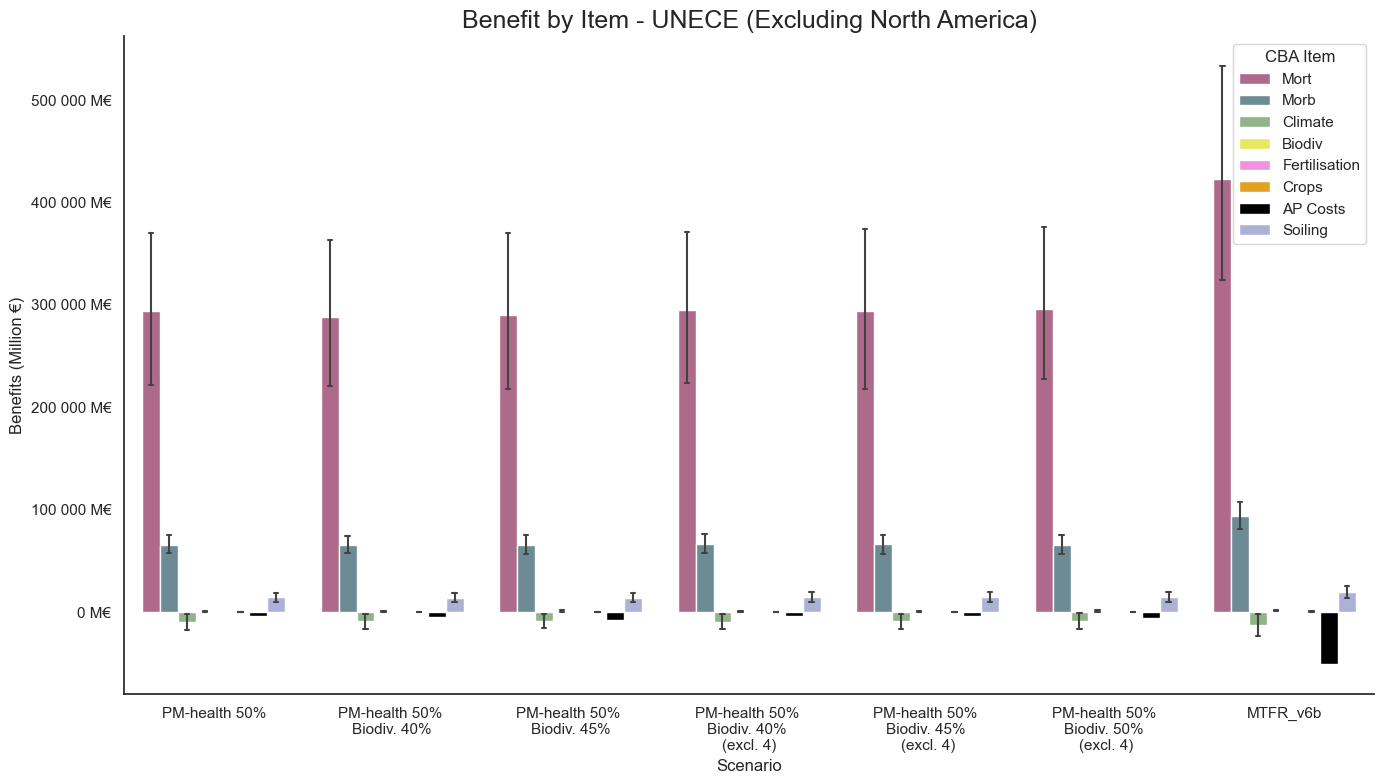

In [235]:
sns.set_theme(style="white")

palette = {
    "Mort": "#b95f89",
    "Morb": "#658e9c",
    "Climate": "#8cba80",
    "Biodiv": "#FCFF4B",
    "Fertilisation": "#ff84e8",
    "Crops": "#FFAD05",
    "Soiling": "#A7ABDD",
    "AP Costs":"#000000"
}

fig, ax = plt.subplots(figsize=(14, 8))  # ← större figur

sns.barplot(
    data=df_all_barchart_summed,
    x="Scenario",
    y="Benefits_million",
    hue="CBA Item",
    palette=palette,
    capsize=0.2,
    err_kws={'linewidth': 1.5},
    ax=ax
)

# Formattera y-axel
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ") + " M€")
)

# Labels & titel
ax.set_ylabel("Benefits (Million €)")
ax.set_title("Benefit by Item - UNECE (Excluding North America)", fontsize=18)

# Force render so tick labels are populated
plt.draw()

ticks = ax.get_xticks()
ax.xaxis.set_major_locator(ticker.FixedLocator(ticks))

new_labels = [
    scenario_plot_labels.get(tick.get_text(), tick.get_text())
    for tick in ax.get_xticklabels()
]
ax.set_xticklabels(new_labels)

# Ta bort top/right spines (ytterlinjer)
sns.despine()

# (valfritt) flytta legend så den inte kläms
ax.legend(title="CBA Item", loc="upper right")

plt.tight_layout()
plt.savefig(r"Plots/barchart_health_climate_fert_crop_biodiv_soil_v6.png", bbox_inches="tight")
plt.show()

### Bar plot per pollutant

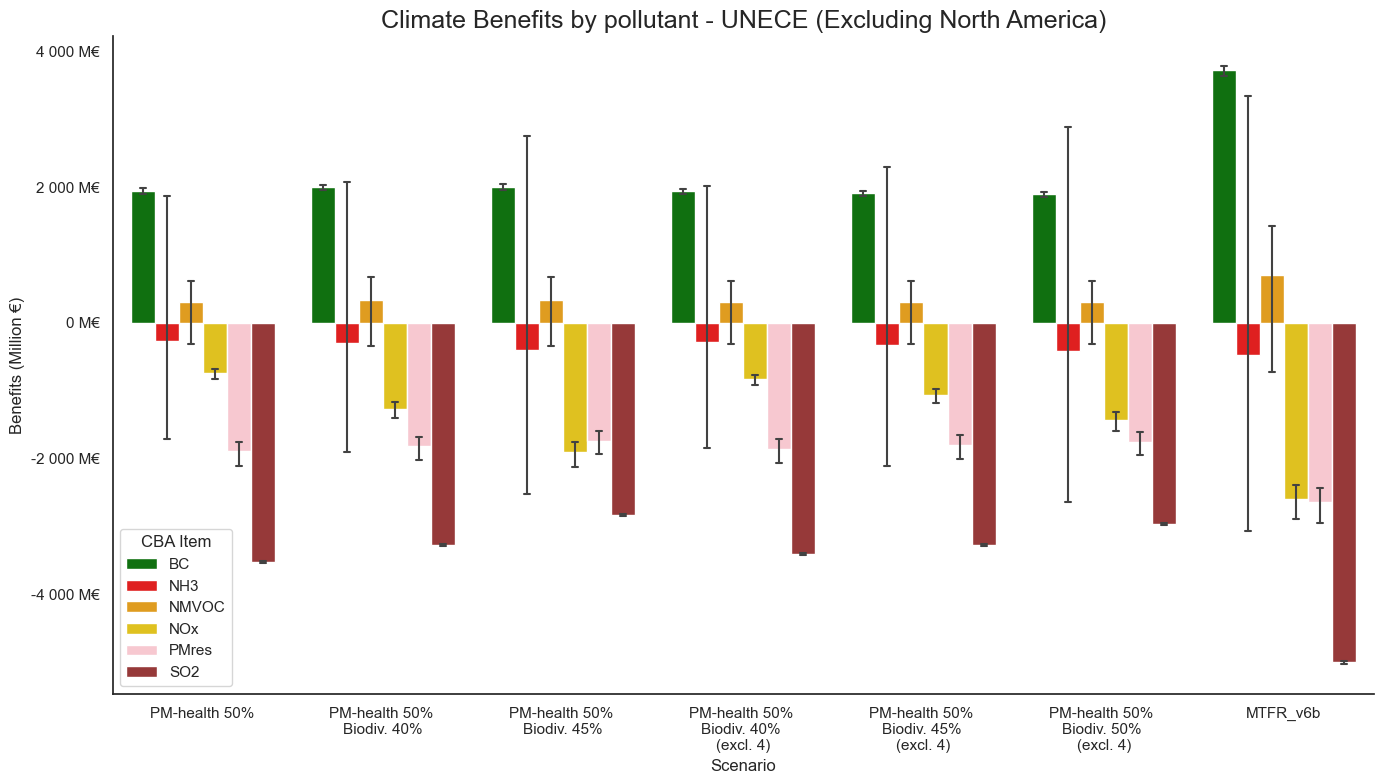

In [236]:
sns.set_theme(style="white")

palette = {
    "BC": "green",
    "CH4": "turquoise",
    "NH3": "red",
    "NMVOC": "orange",
    "NOx": "gold",
    "PMres": "pink",
    "SO2": "brown"
}

fig, ax = plt.subplots(figsize=(14, 8))  # ← större figur

sns.barplot(
    data=df_poll_barchart_filtered,
    x="Scenario",
    y="Benefits_million",
    hue="Pollutant",
    palette=palette,
    capsize=0.2,
    err_kws={'linewidth': 1.5},
    ax=ax
)

# Formattera y-axel
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ") + " M€")
)

# Labels & titel
ax.set_ylabel("Benefits (Million €)")
ax.set_title("Climate Benefits by pollutant - UNECE (Excluding North America)", fontsize=18)

# Force render so tick labels are populated
plt.draw()

ticks = ax.get_xticks()
ax.xaxis.set_major_locator(ticker.FixedLocator(ticks))

new_labels = [
    scenario_plot_labels.get(tick.get_text(), tick.get_text())
    for tick in ax.get_xticklabels()
]
ax.set_xticklabels(new_labels)

# Ta bort top/right spines (ytterlinjer)
sns.despine()

# (valfritt) flytta legend så den inte kläms
ax.legend(title="CBA Item", loc="lower left")

plt.tight_layout()

plt.savefig(r"Plots/barchart_climate_per_poll_v6.png", bbox_inches="tight")
plt.show()

### Box and Whiskers Plot ALL

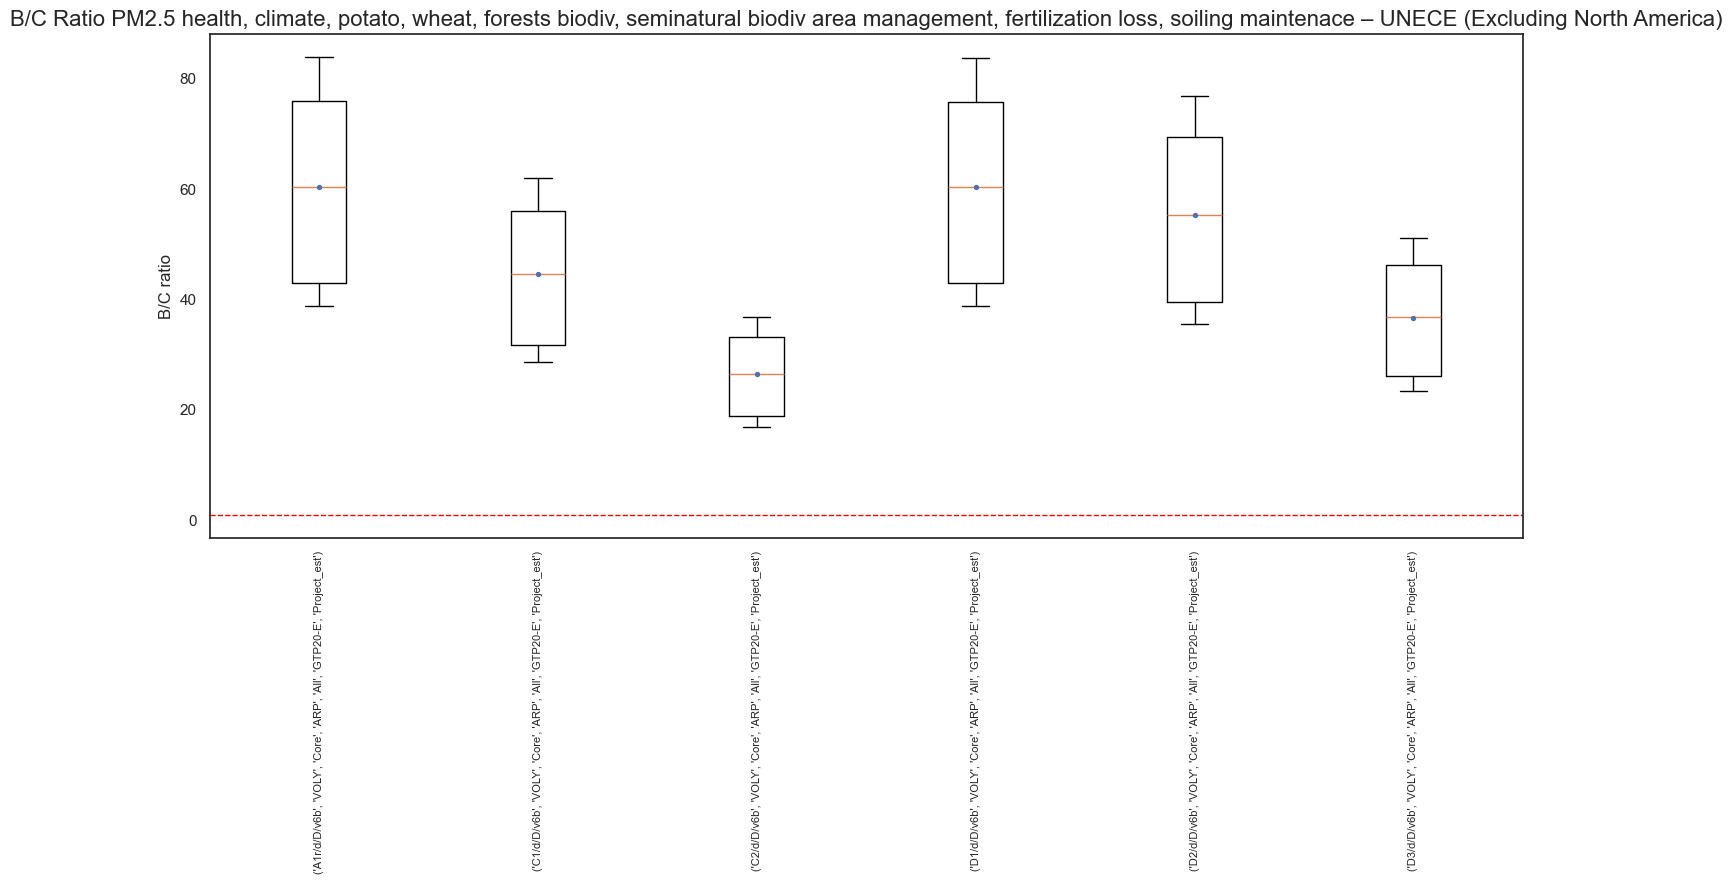

In [237]:
# Get all group names (dictionary keys) and sort them alphabetically
# Each key in "groups" represents one boxplot category
names = sorted(groups_box.keys())

# Build the data list:
data = [groups_box[name]["BC Ratio"] for name in names]

# Number of valid groups
n = len(data)

# Dynamically scale figure width depending on number of boxplots
# Each box gets approx. 0.25 inches of horizontal space
fig_w = max(14, n * 0.25)
fig, ax = plt.subplots(figsize=(fig_w, 9))

ax.set_title("B/C Ratio PM2.5 health, climate, potato, wheat, forests biodiv, seminatural biodiv area management, fertilization loss, soiling maintenace – UNECE (Excluding North America)", fontsize=16)

# Create boxplots:
# - widths=0.25 makes boxes narrow
# - showfliers=False hides extreme outliers (improves readability for many boxes)
bp = ax.boxplot(
    data,
    widths=0.25,
    showfliers=False,
    patch_artist=False
)

# Configure x-axis ticks
ticks = np.arange(1, n + 1)
ax.set_xticks(ticks)

# To avoid overcrowding labels, show only every 8th label
step = 4 if n > 80 else 1
labels = [
    name if (i % step == 0) else ""
    for i, name in enumerate(names, start=1)
]

ax.set_xticklabels(labels, rotation=90, ha="center", fontsize=8)

# Y-axis label
ax.set_ylabel("B/C ratio")

# Add a mean marker (blue dot) for each box
means = [np.mean(v) for v in data]
ax.scatter(ticks, means, s=8, zorder=3)

# Reduce horizontal margins slightly
ax.margins(x=0.002)

ax.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.tight_layout()

plt.savefig(r"Plots\boxplots_all_parts_v6.png", dpi=300, bbox_inches="tight")

plt.show()

### Box and Whiskers Plot per COUNTRY and two scenarios

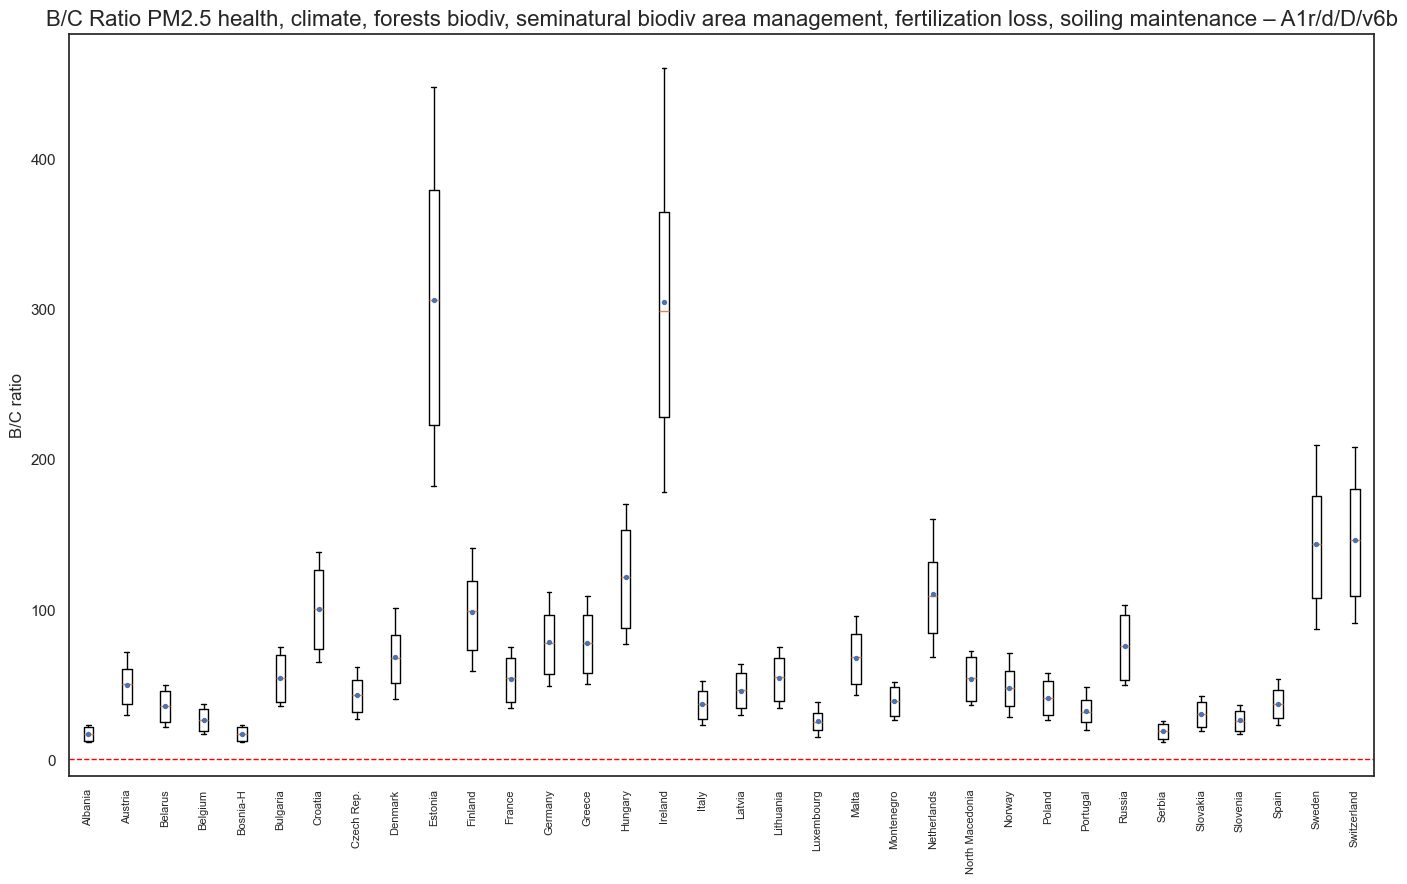

In [238]:
# Get all group names (dictionary keys) and sort them alphabetically
# Each key in "groups" represents one boxplot category
names = sorted(groups_box_country_scen1.keys())

# Build the data list:
data = [groups_box_country_scen1[name]["BC Ratio"] for name in names]

# Number of valid groups
n = len(data)

# Dynamically scale figure width depending on number of boxplots
# Each box gets approx. 0.25 inches of horizontal space
fig_w = max(14, n * 0.25)
fig, ax = plt.subplots(figsize=(fig_w, 9))

ax.set_title("B/C Ratio PM2.5 health, climate, forests biodiv, seminatural biodiv area management, fertilization loss, soiling maintenance – A1r/d/D/v6b", fontsize=16)

# Create boxplots:
# - widths=0.25 makes boxes narrow
# - showfliers=False hides extreme outliers (improves readability for many boxes)
bp = ax.boxplot(
    data,
    widths=0.25,
    showfliers=False,
    patch_artist=False
)

# Configure x-axis ticks
ticks = np.arange(1, n + 1)
ax.set_xticks(ticks)

# To avoid overcrowding labels, show only every 8th label
step = 4 if n > 80 else 1

country_labels = [name[0] for name in names]

labels = [
    country_labels[i-1] if (i % step == 0) else ""
    for i in range(1, n + 1)
]

ax.set_xticklabels(labels, rotation=90, ha="center", fontsize=8)

# Y-axis label
ax.set_ylabel("B/C ratio")

# Add a mean marker (blue dot) for each box
means = [np.mean(v) for v in data]
ax.scatter(ticks, means, s=8, zorder=3)

# Reduce horizontal margins slightly
ax.margins(x=0.002)

ax.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.tight_layout()

plt.savefig(r"Plots\A1rdDv6b_BC_byCountry.png", bbox_inches="tight")

plt.show()

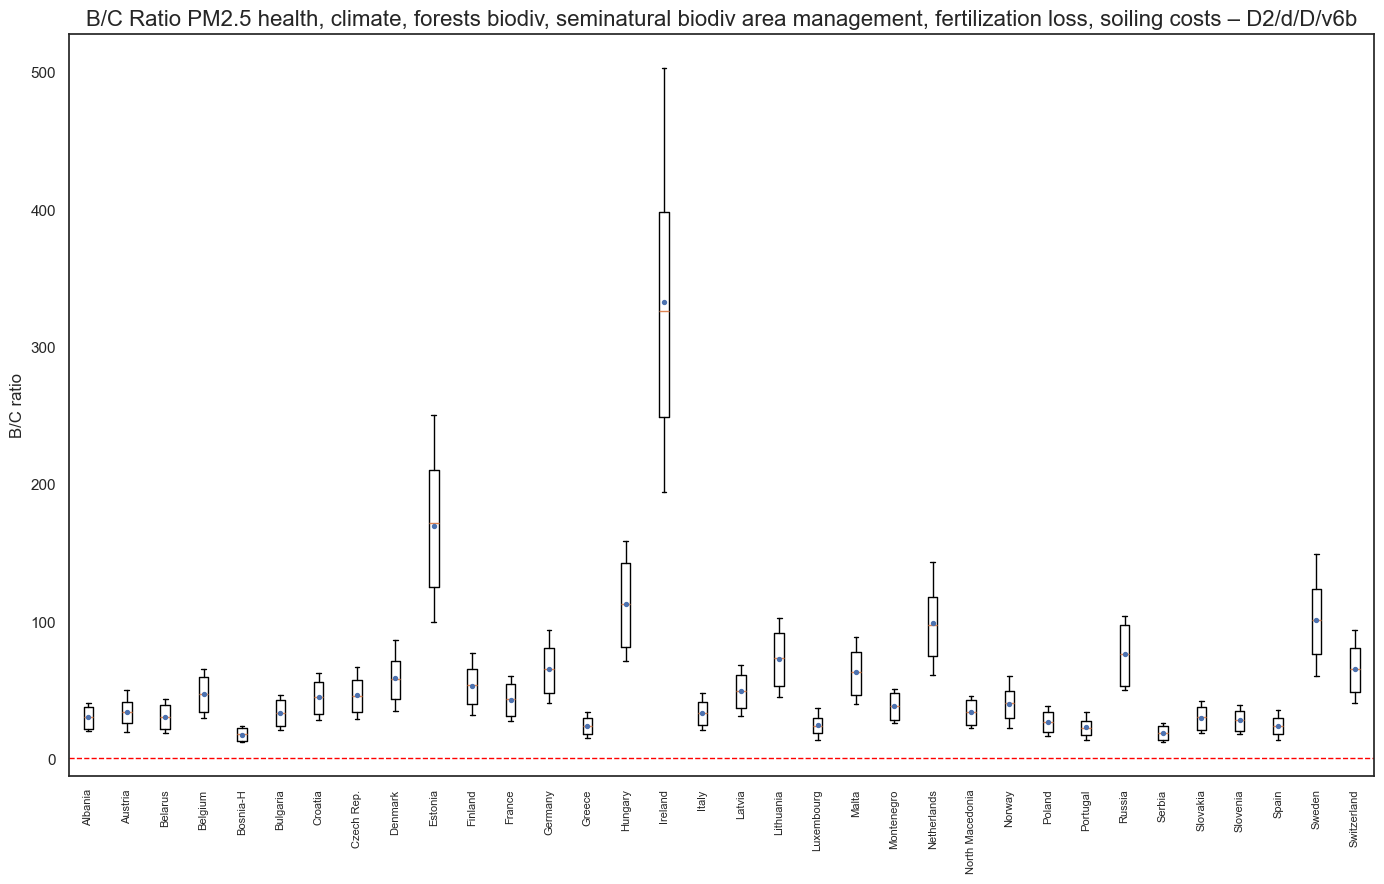

In [239]:
# Get all group names (dictionary keys) and sort them alphabetically
# Each key in "groups" represents one boxplot category
names = sorted(groups_box_country_scen2.keys())

# Build the data list:
data = [groups_box_country_scen2[name]["BC Ratio"] for name in names]

# Number of valid groups
n = len(data)

# Dynamically scale figure width depending on number of boxplots
# Each box gets approx. 0.25 inches of horizontal space
fig_w = max(14, n * 0.25)
fig, ax = plt.subplots(figsize=(fig_w, 9))

ax.set_title("B/C Ratio PM2.5 health, climate, forests biodiv, seminatural biodiv area management, fertilization loss, soiling costs – D2/d/D/v6b", fontsize=16)

# Create boxplots:
# - widths=0.25 makes boxes narrow
# - showfliers=False hides extreme outliers (improves readability for many boxes)
bp = ax.boxplot(
    data,
    widths=0.25,
    showfliers=False,
    patch_artist=False
)

# Configure x-axis ticks
ticks = np.arange(1, n + 1)
ax.set_xticks(ticks)

# To avoid overcrowding labels, show only every 8th label
step = 4 if n > 80 else 1

country_labels = [name[0] for name in names]

labels = [
    country_labels[i-1] if (i % step == 0) else ""
    for i in range(1, n + 1)
]

ax.set_xticklabels(labels, rotation=90, ha="center", fontsize=8)

# Y-axis label
ax.set_ylabel("B/C ratio")

# Add a mean marker (blue dot) for each box
means = [np.mean(v) for v in data]
ax.scatter(ticks, means, s=8, zorder=3)

# Reduce horizontal margins slightly
ax.margins(x=0.002)

ax.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.tight_layout()

plt.savefig(r"Plots\D2dDv6b_BC_byCountry.png", bbox_inches="tight")

plt.show()